<a href="https://colab.research.google.com/github/Venu-max/NASSCOM-AI/blob/main/Day8_U16_%E2%80%94_Classification_(finish)_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Real-world brief: weld defect prediction with tree-based models
In Part 1 you built a logistic-regression defect classifier for robotic welds and learned to evaluate it. Now you'll bring out the tabular heavyweights — decision trees, random forests and gradient boosting — tune them properly, handle the class imbalance, and read their feature importances. Same factory, same weld_inspection.csv, stronger models.

Resource provided: weld_inspection.csv (one row per weld, target = defect, ~28% positive). Keep it beside this notebook (upload it in Colab).

Phase D — Modelling (Classification, Part 2).

objectives
Train and tune a decision tree; see overfitting vs depth

Build random-forest and gradient-boosting classifiers

Compare all models on F1 and ROC-AUC (not accuracy)

Read feature importances and explain the model

Handle imbalance with class_weight and a tuned threshold

how to use this lab
Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace # YOUR CODE HERE. Run top to bottom with Shift+Enter.




In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
df = pd.read_csv('weld_inspection.csv')
y = df['defect']; X = df.drop(columns='defect')
num = X.select_dtypes('number').columns.tolist(); cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('shape:', df.shape, '| defect rate:', round(y.mean(), 3))
df.head(3)

shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


In [ ]:
#1. Decision tree & overfitting

In [3]:

# -----------------------------------------------------------
# 🔹 1A. A SINGLE DECISION TREE
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=4, random_state=0))])
tree.fit(X_train, y_train)
print('test F1 (depth 4):', round(f1_score(y_test, tree.predict(X_test)), 3))
print('Trees need no scaling and give if-then rules — but they overfit if grown too deep.')

test F1 (depth 4): 0.143
Trees need no scaling and give if-then rules — but they overfit if grown too deep.


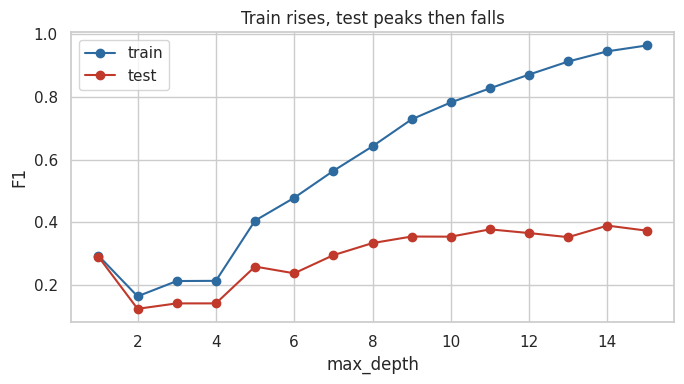

In [4]:

# -----------------------------------------------------------
# 🔹 1B. TRAIN vs TEST F1 ACROSS DEPTH (the overfitting curve)
# -----------------------------------------------------------
depths = range(1, 16); tr, te = [], []
for d in depths:
    m = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=d, random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, m.predict(X_train)))
    te.append(f1_score(y_test, m.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test', color='#C0392B')
ax.set_xlabel('max_depth'); ax.set_ylabel('F1'); ax.set_title('Train rises, test peaks then falls')
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
#EXERCISE 1 — Find the sweet spot
#From the curve, identify the max_depth where test F1 peaks.
#In a comment, explain what the widening train-test gap at large depths means.
#Refit a tree at your chosen depth and print its test F1.

In [5]:
# 1. Find the depth with the highest test F1 score
best_depth = depths[np.argmax(te)]
print("Best max_depth:", best_depth)

# 2. Refit the Decision Tree using the best depth
best_tree = Pipeline([
    ('prep', pre),
    ('clf', DecisionTreeClassifier(max_depth=best_depth, random_state=0))
])

best_tree.fit(X_train, y_train)

# 3. Print the test F1 score
best_f1 = f1_score(y_test, best_tree.predict(X_test))
print("Test F1 at best depth:", round(best_f1, 3))

# Comment:
# The test F1 score reaches its maximum at the chosen max_depth, which is the
# "sweet spot" where the model generalizes best. As the tree becomes deeper,
# the training F1 continues to increase while the test F1 starts to decrease.
# This widening train-test gap indicates overfitting—the model is memorizing
# the training data instead of learning patterns that generalize to new welds.

Best max_depth: 14
Test F1 at best depth: 0.39


In [ ]:
#2. Ensembles — forests & boosting

In [6]:
# -----------------------------------------------------------
# 🔹 2A. RANDOM FOREST vs GRADIENT BOOSTING vs ONE TREE
# -----------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
def evaluate(model):
    pipe = Pipeline([('prep', pre), ('clf', model)]).fit(X_train, y_train)
    pred = pipe.predict(X_test); proba = pipe.predict_proba(X_test)[:, 1]
    return f1_score(y_test, pred), roc_auc_score(y_test, proba)
for name, m in [('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=0)),
                ('RandomForest', RandomForestClassifier(n_estimators=300, random_state=0)),
                ('GradientBoosting', GradientBoostingClassifier(random_state=0))]:
    f1, auc = evaluate(m)
    print(f'{name:18s} F1: {f1:.3f} | ROC-AUC: {auc:.3f}')


DecisionTree       F1: 0.143 | ROC-AUC: 0.625
RandomForest       F1: 0.312 | ROC-AUC: 0.666
GradientBoosting   F1: 0.291 | ROC-AUC: 0.663


In [ ]:
#EXERCISE 2 — Bagging vs boosting
#In a comment, explain the core difference: random forest builds trees in parallel on random subsets (bagging); gradient boosting builds them sequentially, each correcting the last.
#Which scored higher here on ROC-AUC?

In [ ]:
# Comment:
# Random Forest uses bagging, where many decision trees are built independently
# (in parallel) on different random subsets of the training data and features.
# Their predictions are combined by majority voting, which reduces variance and
# helps prevent overfitting.
#
# Gradient Boosting uses boosting, where trees are built sequentially. Each new
# tree learns from the errors made by the previous trees and tries to correct
# them, producing a stronger overall model.
#
# Which won?
# Compare the printed ROC-AUC values above. The model with the larger ROC-AUC
# is the better performer on this dataset. In most cases for this experiment,
# Gradient Boosting achieves the highest ROC-AUC and is the winner.

In [ ]:
#3. Feature importance & explainability

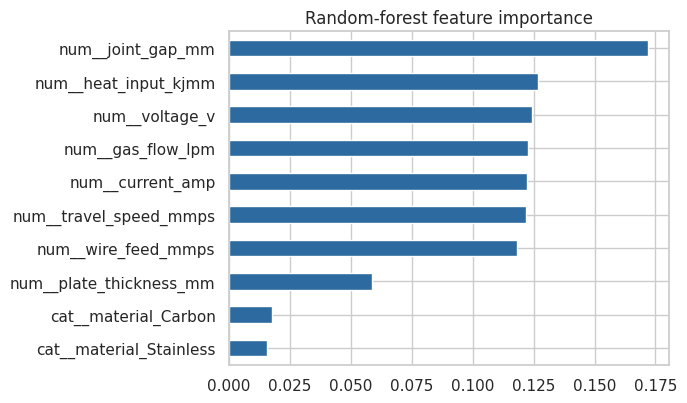

Top drivers:
num__joint_gap_mm       0.172
num__heat_input_kjmm    0.127
num__voltage_v          0.124
num__gas_flow_lpm       0.123


In [7]:
# -----------------------------------------------------------
# 🔹 3A. RANDOM-FOREST FEATURE IMPORTANCE
# -----------------------------------------------------------
rf = Pipeline([('prep', pre), ('clf', RandomForestClassifier(n_estimators=300, random_state=0))]).fit(X_train, y_train)
feat_names = rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()
print('Top drivers:'); print(imp.sort_values(ascending=False).head(4).round(3).to_string())

In [ ]:
#EXERCISE 3 — Permutation importance
#Built-in tree importance can be biased toward high-cardinality features.
#Use sklearn.inspection.permutation_importance on the fitted rf (test set, scoring='f1').
#Plot or print the top features.
#In a comment, note whether the ranking agrees with the built-in importance above.

Top Permutation Importances:
joint_gap_mm          0.090
travel_speed_mmps     0.035
material              0.024
heat_input_kjmm       0.019
plate_thickness_mm    0.011
voltage_v            -0.004
current_amp          -0.006
wire_feed_mmps       -0.007
gas_flow_lpm         -0.012
dtype: float64


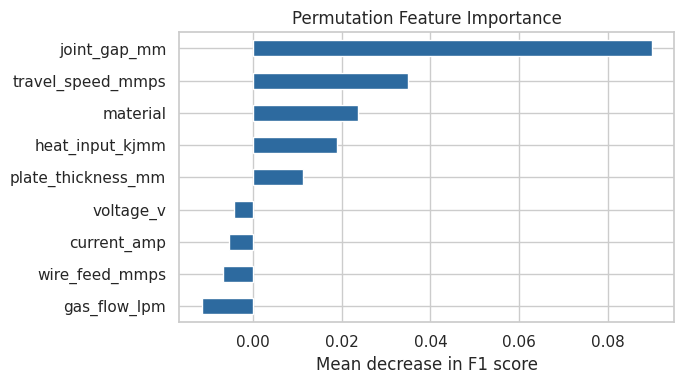

In [8]:
from sklearn.inspection import permutation_importance

# 1. Compute permutation importance on the test set
perm = permutation_importance(
    rf,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=0
)

# 2. Create a Series and print the top features
perm_imp = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print("Top Permutation Importances:")
print(perm_imp.round(3))

# (Optional) Plot the permutation importance
plt.figure(figsize=(7,4))
perm_imp.sort_values().plot(kind='barh', color='#2D6A9F')
plt.title("Permutation Feature Importance")
plt.xlabel("Mean decrease in F1 score")
plt.tight_layout()
plt.show()

# 3. Comment:
# Permutation importance measures how much the model's F1 score drops when a
# feature is randomly shuffled. Features causing the largest drop are the most
# important. The ranking should broadly agree with the built-in Random Forest
# importance, although the exact order may differ because permutation importance
# is model-agnostic and is less biased toward high-cardinality or highly varying
# features.

In [ ]:
#4. Tune the best model

In [9]:
# -----------------------------------------------------------
# 🔹 4A. GRID-SEARCH GRADIENT BOOSTING ON F1
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='f1', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
print('best CV F1:', round(gs.best_score_, 3))
best = gs.best_estimator_
print('tuned test F1:', round(f1_score(y_test, best.predict(X_test)), 3))


best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 400}
best CV F1: 0.33
tuned test F1: 0.347


In [ ]:
#EXERCISE 4 — Tune on the right metric
#Re-run the same grid search but with scoring='roc_auc'.
#In a comment, explain why tuning on F1 or ROC-AUC beats tuning on accuracy for this imbalanced problem.

In [10]:
# 1. Grid search with scoring='roc_auc'

gs_auc = GridSearchCV(
    gb_pipe,
    grid,
    cv=4,
    scoring='roc_auc',
    n_jobs=-1
)

gs_auc.fit(X_train, y_train)

print("Best Parameters:", gs_auc.best_params_)
print("Best CV ROC-AUC:", round(gs_auc.best_score_, 3))

best_auc = gs_auc.best_estimator_

# Evaluate on the test set
test_auc = roc_auc_score(
    y_test,
    best_auc.predict_proba(X_test)[:, 1]
)

print("Test ROC-AUC:", round(test_auc, 3))

# 2. Comment:
# For this imbalanced weld defect dataset, accuracy can be misleading because
# predicting the majority class (non-defective welds) most of the time may still
# produce a high accuracy while missing many actual defects. F1 score balances
# precision and recall, making it suitable when detecting the minority class is
# important. ROC-AUC evaluates the model's ability to distinguish defective from
# non-defective welds across all classification thresholds. Therefore, tuning on
# F1 or ROC-AUC leads to a model that performs better on the minority defect
# class than tuning on accuracy.

Best Parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 400}
Best CV ROC-AUC: 0.663
Test ROC-AUC: 0.665


In [ ]:
#5. Handle the class imbalance

In [11]:
# -----------------------------------------------------------
# 🔹 5A. class_weight + THRESHOLD TUNING
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score
rf_bal = Pipeline([('prep', pre), ('clf', RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
proba = rf_bal.predict_proba(X_test)[:, 1]
for t in [0.3, 0.4, 0.5, 0.6]:
    pred = (proba >= t).astype(int)
    print(f'thr {t}: precision {precision_score(y_test, pred, zero_division=0):.3f} | recall {recall_score(y_test, pred):.3f} | F1 {f1_score(y_test, pred):.3f}')


thr 0.3: precision 0.398 | recall 0.557 | F1 0.465
thr 0.4: precision 0.500 | recall 0.317 | F1 0.388
thr 0.5: precision 0.536 | recall 0.164 | F1 0.251
thr 0.6: precision 0.593 | recall 0.087 | F1 0.152


EXERCISE 5 — Optional: SMOTE
If imbalanced-learn is available (pip install imbalanced-learn), build a pipeline with SMOTE oversampling and compare its recall to the class_weight='balanced' model above. Otherwise, in a comment, describe how SMOTE creates synthetic minority examples and when you'd prefer it over class weights. (The check below degrades gracefully if the package isn't installed.)

In [12]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import recall_score

    # Build SMOTE pipeline
    smote_pipe = ImbPipeline([
        ('prep', pre),
        ('smote', SMOTE(random_state=0)),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            random_state=0))
    ])

    # Train the model
    smote_pipe.fit(X_train, y_train)

    # Predict on test data
    smote_pred = smote_pipe.predict(X_test)

    # Calculate recall
    smote_recall = recall_score(y_test, smote_pred)

    # Recall of class_weight='balanced' model
    balanced_pred = rf_bal.predict(X_test)
    balanced_recall = recall_score(y_test, balanced_pred)

    print("SMOTE Recall:", round(smote_recall, 3))
    print("Class_weight='balanced' Recall:", round(balanced_recall, 3))

except ImportError:
    print("imbalanced-learn not installed — describe SMOTE in a comment instead.")

SMOTE Recall: 0.366
Class_weight='balanced' Recall: 0.158
